# <u>Chargement des données<u> :

In [1]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("online_retail.db")

# Vérifier que toutes tes tables sont bien là
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)
print(tables)

                  name
0        online_retail
1              Invoice
2               orders
3             Products
4  online_retail_clean
5            Customers
6             commande
7        LigneCommande
8          no_Products
9              Product


# <u>VUE D'ENSEMBLE :</u>

## Quel est le CA total ? 

In [2]:
query_ca_total = """
SELECT SUM(Quantity * UnitPrice) AS ca_total
FROM online_retail_clean
"""
df_ca_total = pd.read_sql(query_ca_total, conn)
df_ca_total

,ca_total
0,9804459.303


## Quel est le CA par pays ?

In [3]:
query_ca_pays = """
SELECT Country, SUM(Quantity * UnitPrice) AS ca_pays
FROM online_retail_clean
GROUP BY Country
ORDER BY ca_pays DESC
LIMIT 10
"""
df_ca_pays = pd.read_sql(query_ca_pays, conn)
df_ca_pays

,Country,ca_pays
0,United Kingdom,8313468.703
1,Netherlands,283479.540
2,EIRE,259663.460
3,Germany,200808.400
4,France,182163.390
5,Australia,136990.000
6,Switzerland,52505.350
7,Spain,51765.200
8,Belgium,36662.960
9,Japan,35419.790


### Graphique CA par pays : Treemap

In [4]:
!pip install squarify

In [5]:
import squarify
import matplotlib.pyplot as plt

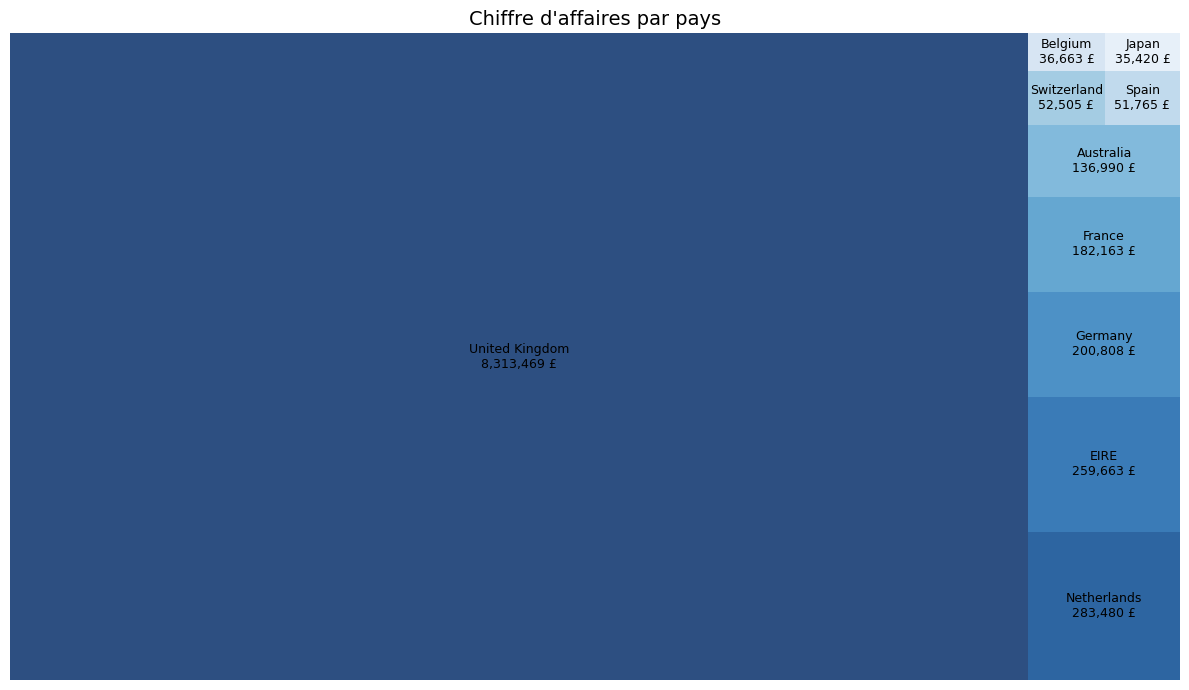

In [6]:
plt.figure(figsize=(12, 7))
colors = plt.cm.Blues_r([i/len(df_ca_pays) for i in range(len(df_ca_pays))])

squarify.plot(
    sizes=df_ca_pays['ca_pays'],
    label=[f"{c}\n{v:,.0f} £" for c, v in zip(df_ca_pays['Country'], df_ca_pays['ca_pays'])],
    color=colors,
    alpha=0.85,
    text_kwargs={'fontsize': 9}
)
plt.title("Chiffre d'affaires par pays", fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()

## Quel est l'impact des annulations sur le CA ?

In [7]:
query_annulations = """
SELECT
    SUM(CASE WHEN CancelInvoice = 1 THEN quantity * Unitprice ELSE 0 END) AS ca_annulations,
    SUM(quantity * unitprice) AS ca_total,
    ROUND(
         100.0 * SUM(CASE WHEN CancelInvoice = 1 THEN Quantity * UnitPrice ELSE 0 END)
        / SUM(Quantity * UnitPrice), 2) AS pourcentage_annulations
FROM online_retail_clean
"""
df_annulations = pd.read_sql(query_annulations, conn)
df_annulations

,ca_annulations,ca_total,pourcentage_annulations
0,-478724.18,9804459.303,-4.88


### moins de 5 % de perte liée aux annulations (raisonnable pour une activité e-commerce)
### graphique = camembert

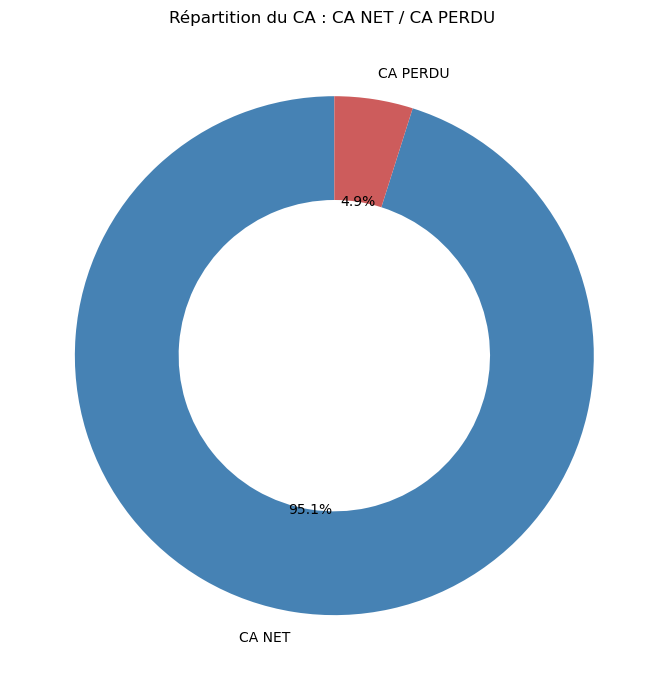

In [8]:
ca_net = df_annulations['ca_total'][0] + df_annulations['ca_annulations'][0] # ca_annulations négatif
ca_perdu = abs(df_annulations['ca_annulations'][0])

plt.figure(figsize=(7, 7))
plt.pie(
    [ca_net, ca_perdu ],
    labels=['CA NET', 'CA PERDU'],
    autopct='%1.1f%%',
    colors=['steelblue', 'indianred'],
    startangle=90,
    wedgeprops={'width': 0.4}
)
plt.title("Répartition du CA : CA NET / CA PERDU ")
plt.tight_layout()
plt.show()

## Quelle part du CA provient des CustomerID sans identifiant ?

In [9]:
query_null_customer = """
SELECT
    SUM(CASE WHEN CustomerID IS NULL THEN Quantity * UnitPrice ELSE 0 END) AS ca_sans_client,
    SUM(CASE WHEN CustomerID IS NOT NULL THEN Quantity * UnitPrice ELSE 0 END) AS ca_avec_client,
    SUM(Quantity * UnitPrice) AS ca_total,
    ROUND(
        100.0 * SUM(CASE WHEN CustomerID IS NULL THEN Quantity * UnitPrice ELSE 0 END)
        / SUM(Quantity * UnitPrice), 2
    ) AS pourcentage_sans_client
FROM online_retail_Clean
"""
df_null_customer = pd.read_sql(query_null_customer, conn)
df_null_customer

,ca_sans_client,ca_avec_client,ca_total,pourcentage_sans_client
0,1517795.98,8286663.323,9804459.303,15.48


### les commandes sans identifiant client représentent presque 16 % du CA. 
### Graphique : camembert

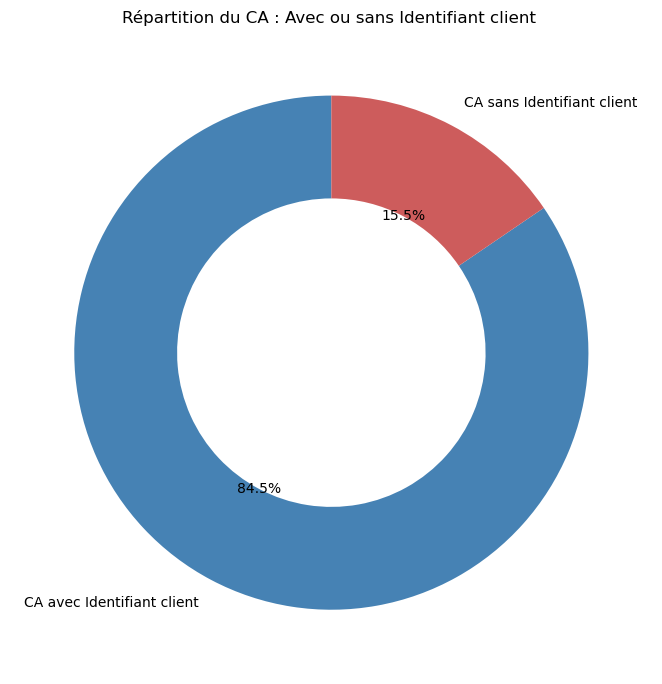

In [10]:
ca_avec_ID = df_null_customer['ca_avec_client'][0] 
ca_sans_ID = df_null_customer['ca_sans_client'][0]

plt.figure(figsize=(7, 7))
plt.pie(
    [ca_avec_ID, ca_sans_ID ],
    labels=['CA avec Identifiant client', 'CA sans Identifiant client'],
    autopct='%1.1f%%',
    colors=['steelblue', 'indianred'],
    startangle=90,
    wedgeprops={'width': 0.4}
)
plt.title("Répartition du CA : Avec ou sans Identifiant client ")
plt.tight_layout()
plt.show()

# <u>Produits</u> :

## Quel produit est le plus vendu par pays ? 

In [13]:
query_top_produit_pays10 = """
SELECT Country, Description, quantite_totale
FROM (
    SELECT
        Country,
        Description,
        SUM(Quantity) AS quantite_totale,
        RANK() OVER (PARTITION BY Country ORDER BY SUM(Quantity) DESC) AS rang
    FROM online_retail_clean
    WHERE Quantity > 0
    GROUP BY Country, Description
)
WHERE rang = 1
AND Country IN (
    SELECT Country FROM (
        SELECT Country, SUM(Quantity * UnitPrice) AS ca
        FROM online_retail_clean
        GROUP BY Country
        ORDER BY ca DESC
        LIMIT 10
    )
)
ORDER BY quantite_totale DESC
"""
df_top_produit_pays10 = pd.read_sql(query_top_produit_pays10, conn)
df_top_produit_pays10

,Country,Description,quantite_totale
0,United Kingdom,"PAPER CRAFT , LITTLE BIRDIE",80995
1,Netherlands,RABBIT NIGHT LIGHT,4801
2,France,RABBIT NIGHT LIGHT,4024
3,Japan,RABBIT NIGHT LIGHT,3408
4,Australia,MINI PAINT SET VINTAGE,2952
5,EIRE,PACK OF 72 RETROSPOT CAKE CASES,1800
6,Germany,ROUND SNACK BOXES SET OF4 WOODLAND,1233
7,Spain,CHILDRENS CUTLERY POLKADOT PINK,729
8,Switzerland,PLASTERS IN TIN WOODLAND ANIMALS,639
9,Belgium,PACK OF 72 RETROSPOT CAKE CASES,480


## Graphique Top produit

In [15]:
query_top_produit_pays10 = """
SELECT Country, Description, quantite_totale
FROM (
    SELECT
        Country,
        Description,
        SUM(Quantity) AS quantite_totale,
        RANK() OVER (PARTITION BY Country ORDER BY SUM(Quantity) DESC) AS rang
    FROM online_retail_clean
    WHERE Quantity > 0
    GROUP BY Country, Description
)
WHERE rang = 1
AND Country IN (
    SELECT Country FROM (
        SELECT Country, SUM(Quantity * UnitPrice) AS ca
        FROM online_retail_clean
        GROUP BY Country
        ORDER BY ca DESC
        LIMIT 10
    )
)
ORDER BY quantite_totale DESC
"""
df_map = pd.read_sql(query_top_produit_pays10, conn)
df_map.head()

,Country,Description,quantite_totale
0,United Kingdom,"PAPER CRAFT , LITTLE BIRDIE",80995
1,Netherlands,RABBIT NIGHT LIGHT,4801
2,France,RABBIT NIGHT LIGHT,4024
3,Japan,RABBIT NIGHT LIGHT,3408
4,Australia,MINI PAINT SET VINTAGE,2952


C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_5272\3899301923.py:2: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


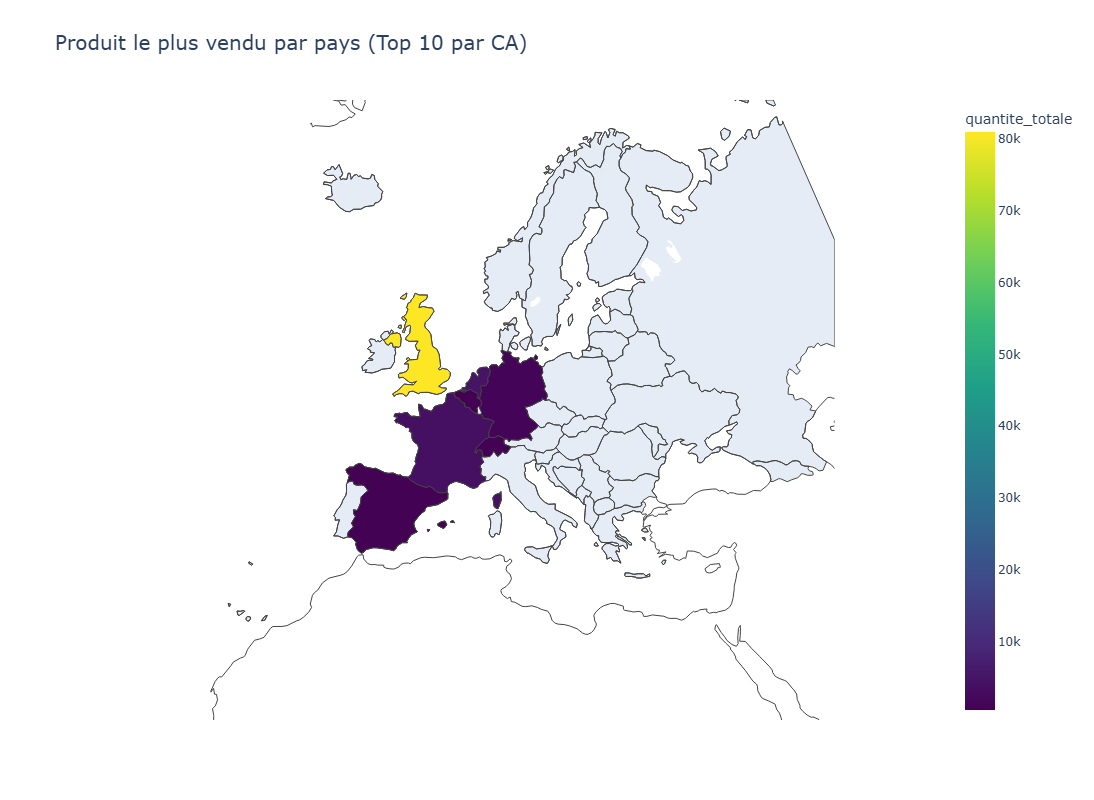

In [16]:
import plotly.express as px
fig = px.choropleth(
    df_map,
    locations="Country",
    locationmode="country names",
    color="quantite_totale",
    hover_name="Country",
    hover_data={"Description": True, "quantite_totale": True},
    color_continuous_scale="Viridis",
    title="Produit le plus vendu par pays (Top 10 par CA)",
    scope="europe"
)

fig.update_layout(
    geo=dict(
        showframe=False,
        showcoastlines=True,
        projection_scale=1.3,  # zoom supplémentaire
        center=dict(lat=50, lon=10)  # recentre sur l'Europe continentale + UK
    ),
    width=1000,
    height=800,
    title_font_size=20
)

fig.show()

## Quels Stockcode restant sur la table clean ne correspondent pas à un produit ?

In [17]:
query_no_products_freq = """
SELECT StockCode, Description, COUNT(*) AS frequence
FROM online_retail_clean
WHERE StockCode NOT GLOB '[0-9]*'
GROUP BY StockCode, Description
ORDER BY frequence DESC
"""
df_no_products_freq = pd.read_sql(query_no_products_freq, conn)
df_no_products_freq

,StockCode,Description,frequence
0,DCGSSGIRL,GIRLS PARTY BAG,13
1,DCGSSBOY,BOYS PARTY BAG,11
2,gift_0001_20,Dotcomgiftshop Gift Voucher £20.00,9
3,gift_0001_10,Dotcomgiftshop Gift Voucher £10.00,8
4,gift_0001_30,Dotcomgiftshop Gift Voucher £30.00,7
5,DCGS0003,BOXED GLASS ASHTRAY,4
6,gift_0001_50,Dotcomgiftshop Gift Voucher £50.00,4
7,PADS,PADS TO MATCH ALL CUSHIONS,3
8,gift_0001_40,Dotcomgiftshop Gift Voucher £40.00,3
9,DCGS0076,SUNJAR LED NIGHT NIGHT LIGHT,2


In [18]:
query_impact_codes = """
SELECT
    SUM(Quantity * UnitPrice) AS ca_codes_douteux,
    (SELECT SUM(Quantity * UnitPrice) FROM online_retail_clean) AS ca_total,
    ROUND(
        100.0 * SUM(Quantity * UnitPrice)
        / (SELECT SUM(Quantity * UnitPrice) FROM online_retail_clean), 2
    ) AS pourcentage_ca
FROM online_retail_clean
WHERE StockCode NOT GLOB '[0-9]*'
"""
df_impact_codes = pd.read_sql(query_impact_codes, conn)
df_impact_codes

,ca_codes_douteux,ca_total,pourcentage_ca
0,12148.873,9804459.303,0.12


**Question à trancher avec la direction** : ces 15 StockCode (bons cadeaux Dotcomgiftshop, sacs de fête DCGS...) sont-ils à considérer comme de vrais produits vendables, ou à exclure de l'analyse produit ?

**Impact sur les calculs** : ces codes représentent seulement 0.12 % du chiffre d'affaires total. les garder ou les exclure ne modifie pas significativement les conclusions de l'analyse. Nous les avons conservés dans la table `Product` par défaut, en attendant clarification.

# <u>CLIENTS : </u>

## TOP 10 Clients : 

In [19]:
import plotly.express as px

In [20]:
query_top10 = """
SELECT CustomerID, SUM(Quantity * UnitPrice) AS CA_client
FROM online_retail_clean
WHERE CustomerID IS NOT NULL
GROUP BY CustomerID
ORDER BY CA_client DESC
LIMIT 10
"""
df_top10_plot = pd.read_sql(query_top10, conn)
df_top10_plot

,CustomerID,CA_client
0,14646.0,278778.02
1,18102.0,259657.30
2,17450.0,189735.53
3,14911.0,128882.13
4,12415.0,123638.18
5,14156.0,113855.32
6,17511.0,88138.20
7,16684.0,65920.12
8,13694.0,62924.10
9,15311.0,59419.34


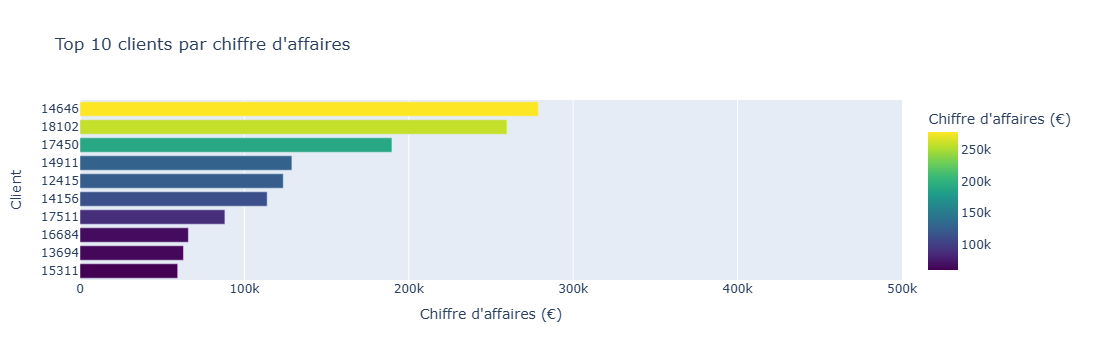

In [21]:
df_top10_plot["CustomerID"] = df_top10_plot["CustomerID"].astype(int).astype(str)       #Conversion des 'CustomerID' en texte (pour ne pas avoir les sommes qui s'affiche)

fig = px.bar(
    df_top10_plot.sort_values("CA_client"),
    x="CA_client",
    y="CustomerID",
    orientation="h",
    title="Top 10 clients par chiffre d'affaires",
    labels={
        "CustomerID": "Client",
        "CA_client": "Chiffre d'affaires (€)"
    },
    color="CA_client",
    color_continuous_scale="Viridis"
)


fig.update_xaxes(range=[0, 500000])                                     #Mettre l'échelle à 1M sinon trop grande

fig.show()

## Calcul pourcentage cumulé du chiffre d'affaires pour chaque client (loi de Pareto)

In [22]:
df_clients = pd.read_sql_query("""
SELECT CustomerID, SUM(Quantity * UnitPrice) AS CA_client
FROM online_retail_clean
WHERE CustomerID IS NOT NULL
GROUP BY CustomerID
ORDER BY CA_client DESC
""", conn)

df_clients.head()

,CustomerID,CA_client
0,14646.0,278778.02
1,18102.0,259657.30
2,17450.0,189735.53
3,14911.0,128882.13
4,12415.0,123638.18


In [23]:
df_clients_pareto = df_clients.copy()
df_clients_pareto["CA_cumule"] = df_clients_pareto["CA_client"].cumsum()
df_clients_pareto["CA_pourcentage_cumule"] = (
    100 * df_clients_pareto["CA_cumule"] / df_clients_pareto["CA_client"].sum()
)
df_clients_pareto.head()

,CustomerID,CA_client,CA_cumule,CA_pourcentage_cumule
0,14646.0,278778.02,278778.02,3.364177
1,18102.0,259657.30,538435.32,6.497613
2,17450.0,189735.53,728170.85,8.787262
3,14911.0,128882.13,857052.98,10.342558
4,12415.0,123638.18,980691.16,11.834572


## Graphique 

In [24]:
import numpy as np
import plotly.graph_objects as go

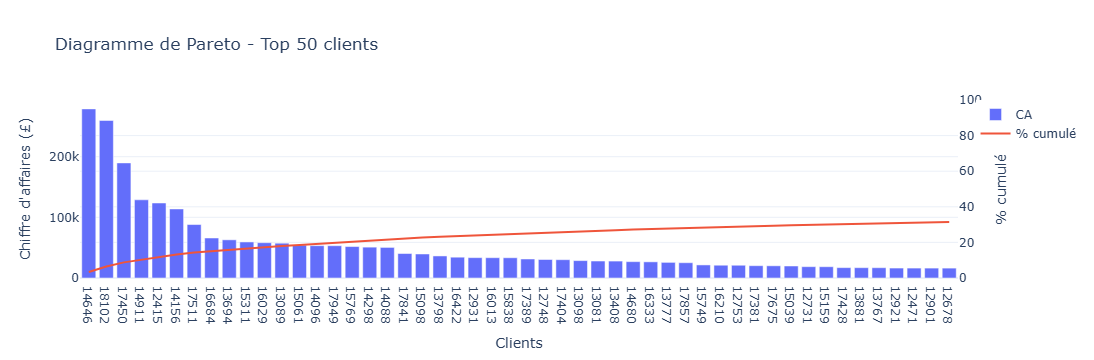

In [39]:
df_top50 = df_clients_pareto.head(50)

fig = go.Figure()

fig.add_bar(
    x=df_top50["CustomerID"].astype(int).astype(str),
    y=df_top50["CA_client"],
    name="CA"
)

fig.add_scatter(
    x=df_top50["CustomerID"].astype(int).astype(str),
    y=df_top50["CA_pourcentage_cumule"],
    mode="lines",
    name="% cumulé",
    yaxis="y2"
)

fig.update_layout(
    title="Diagramme de Pareto - Top 50 clients",
    xaxis_title="Clients",
    yaxis_title="Chiffre d'affaires (£)",
    yaxis2=dict(
        title="% cumulé",
        overlaying="y",
        side="right",
        range=[0, 100]
    ),
    template="plotly_white"
)

fig.show()

## nb de client par pays

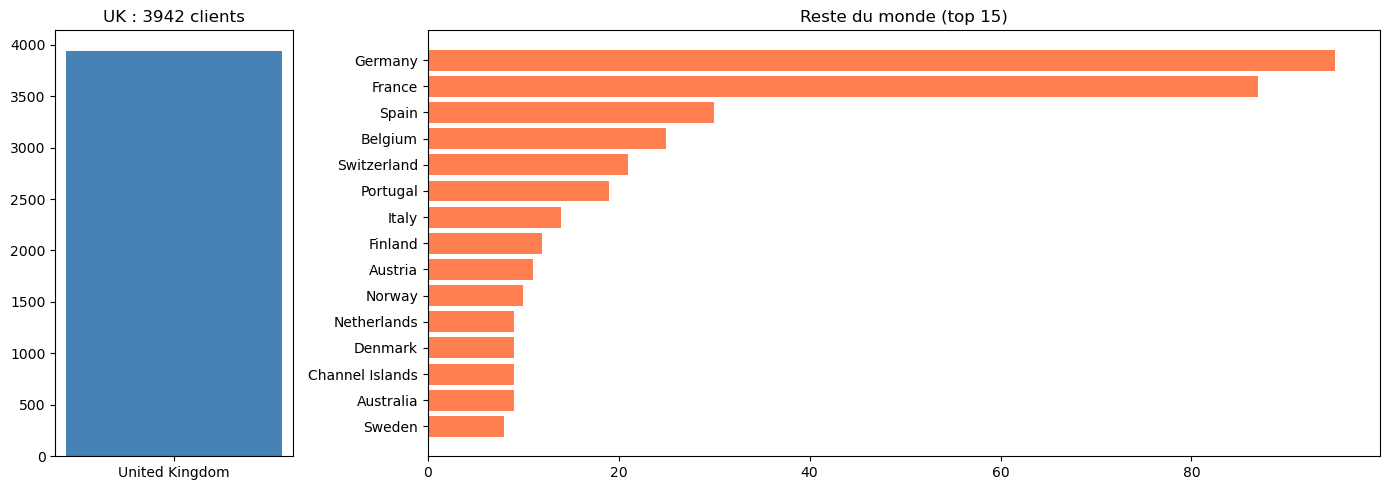

In [26]:
df_clients = pd.read_sql_query("""
    SELECT Country, COUNT(DISTINCT CustomerID) AS nb_clients
    FROM Customers
    GROUP BY Country
    ORDER BY nb_clients DESC;
""", conn)

uk = df_clients[df_clients['Country'] == 'United Kingdom']
reste = df_clients[df_clients['Country'] != 'United Kingdom'].head(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={'width_ratios': [1, 4]})
axes[0].bar(['United Kingdom'], uk['nb_clients'], color='steelblue')
axes[0].set_title(f"UK : {uk['nb_clients'].values[0]} clients")

axes[1].barh(reste['Country'][::-1], reste['nb_clients'][::-1], color='coral')
axes[1].set_title("Reste du monde (top 15)")
plt.tight_layout()
plt.show()

## nb de commande par pays 

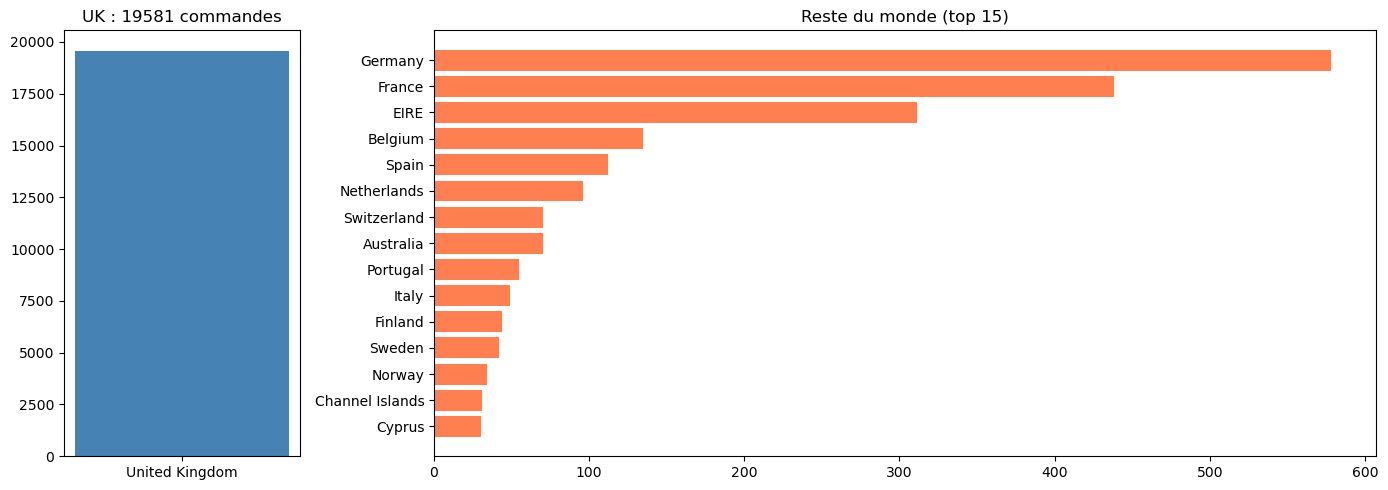

In [27]:
df_commandes = pd.read_sql_query("""
SELECT cu.Country, COUNT(DISTINCT co.InvoiceNo) AS nb_commandes
FROM commande co
JOIN Customers cu ON co.CustomerID = cu.CustomerID
GROUP BY cu.Country
ORDER BY nb_commandes DESC;
""", conn)

uk = df_commandes[df_commandes['Country'] == 'United Kingdom']
reste = df_commandes[df_commandes['Country'] != 'United Kingdom'].head(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={'width_ratios': [1, 4]})

axes[0].bar(['United Kingdom'], uk['nb_commandes'], color='steelblue')
axes[0].set_title(f"UK : {uk['nb_commandes'].values[0]} commandes")

axes[1].barh(reste['Country'][::-1], reste['nb_commandes'][::-1], color='coral')
axes[1].set_title("Reste du monde (top 15)")
plt.tight_layout()
plt.show()

## CA moyen par pays 

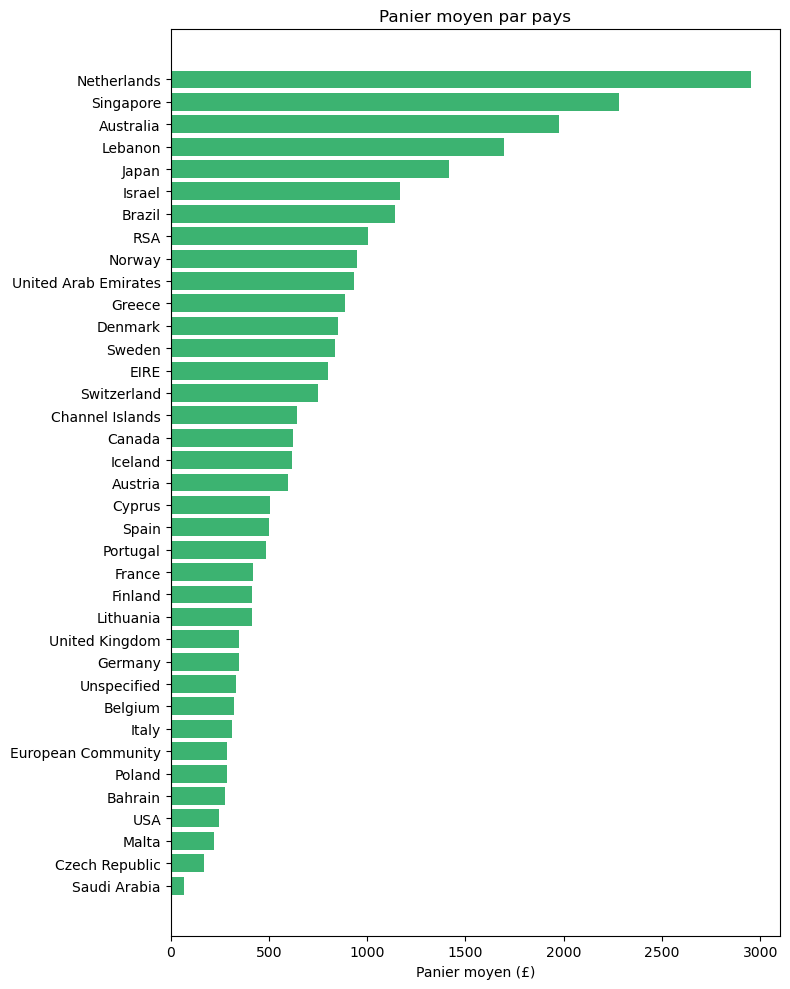

In [28]:
df_panier = pd.read_sql_query("""
SELECT cu.Country, ROUND(AVG(panier.montant),2) AS panier_moyen
FROM (
    SELECT co.InvoiceNo, co.CustomerID, SUM(lc.Quantity * lc.UnitPrice) AS montant
    FROM commande co
    JOIN LigneCommande lc ON co.InvoiceNo = lc.InvoiceNo
    GROUP BY co.InvoiceNo, co.CustomerID
) AS panier
JOIN Customers cu ON panier.CustomerID = cu.CustomerID
GROUP BY cu.Country
ORDER BY panier_moyen DESC;
""", conn)

plt.figure(figsize=(8,10))
plt.barh(df_panier['Country'][::-1], df_panier['panier_moyen'][::-1], color='mediumseagreen')
plt.xlabel("Panier moyen (£)")
plt.title("Panier moyen par pays")
plt.tight_layout()
plt.show()




In [29]:
df_comparatif = df_clients.merge(df_commandes, on="Country").merge(df_panier, on="Country")
df_comparatif.head()
top15_clients = df_clients.nlargest(15, 'nb_clients')['Country']
top15_commandes = df_commandes.nlargest(15, 'nb_commandes')['Country']
top15_panier = df_panier.nlargest(15, 'panier_moyen')['Country']

pays_a_garder = set(top15_clients) | set(top15_commandes) | set(top15_panier)

df_comparatif_top = df_comparatif[df_comparatif['Country'].isin(pays_a_garder)]

print(f"{len(df_comparatif_top)} pays gardés sur {len(df_comparatif)}")

25 pays gardés sur 37


In [42]:
!pip install adjustText
from adjustText import adjust_text


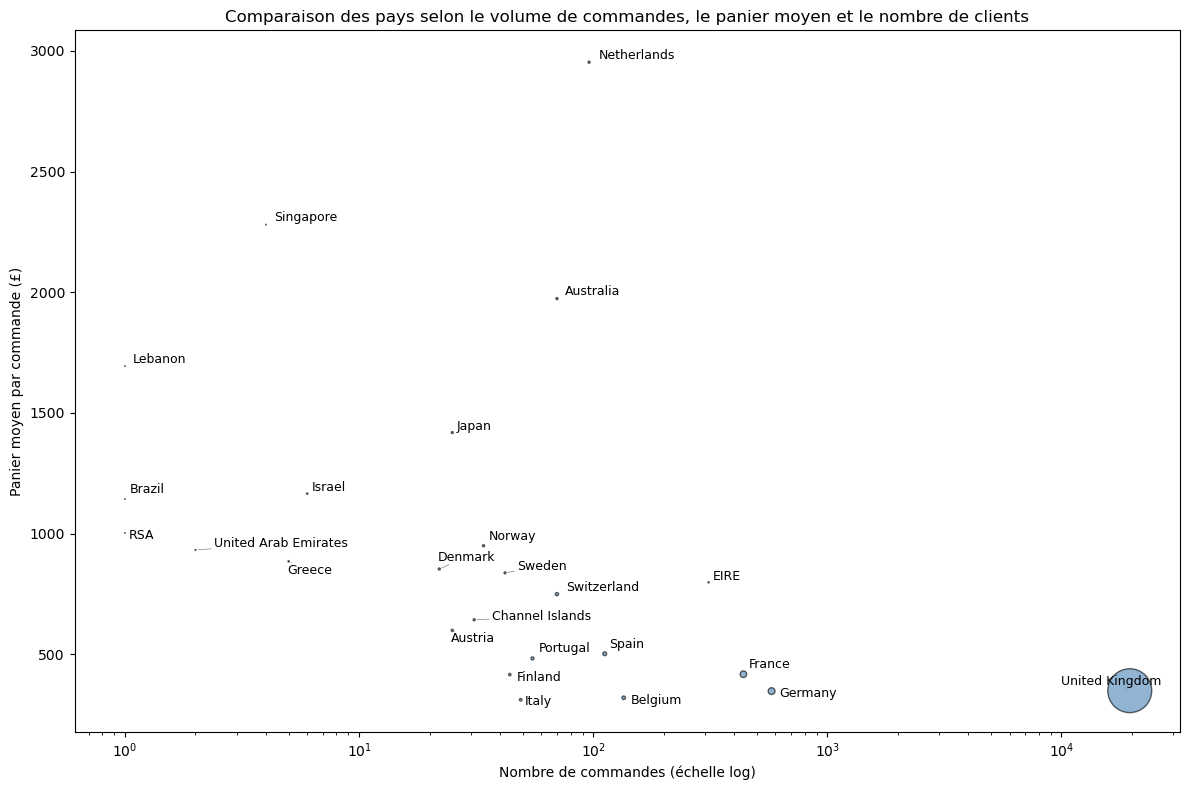

In [43]:
plt.figure(figsize=(12, 8))

# Taille des bulles normalisée pour éviter qu'un pays écrase les autres
tailles = (df_comparatif_top['nb_clients'] / df_comparatif_top['nb_clients'].max()) * 1000

plt.scatter(
    df_comparatif_top['nb_commandes'],
    df_comparatif_top['panier_moyen'],
    s=tailles,
    alpha=0.6,
    color='steelblue',
    edgecolors='black'
)

plt.xscale('log')

texts = []
for _, row in df_comparatif_top.iterrows():
    texts.append(plt.text(row['nb_commandes'], row['panier_moyen'], row['Country'], fontsize=9))

adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

plt.xlabel("Nombre de commandes (échelle log)")
plt.ylabel("Panier moyen par commande (£)")
plt.title("Comparaison des pays selon le volume de commandes, le panier moyen et le nombre de clients")
plt.tight_layout()
plt.show()

# <u>SAISONNALITÉ :</u>

## Les périodes où il y a le plus d'achats ? Le moins ?

In [44]:
query = """
SELECT
    InvoiceDate AS Jour,
    COUNT(DISTINCT InvoiceNo) AS Nombre_Commandes
FROM online_retail_clean
GROUP BY Jour
ORDER BY Jour
"""
jours = pd.read_sql(query, conn)
jours

,Jour,Nombre_Commandes
0,2010-12-01,132
1,2010-12-02,164
2,2010-12-03,75
3,2010-12-05,94
4,2010-12-06,120
...,...,...
300,2011-12-05,139
301,2011-12-06,144
302,2011-12-07,117
303,2011-12-08,140


## Graphique :

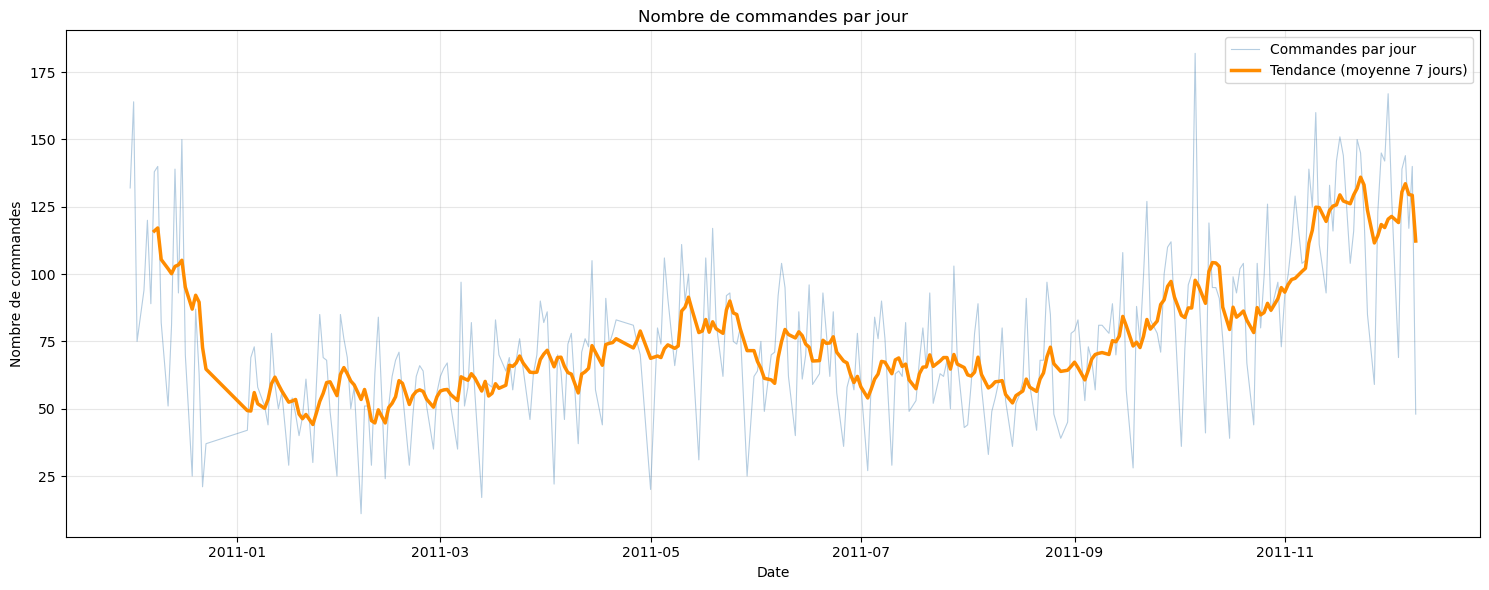

In [54]:
jours["Jour"] = pd.to_datetime(jours["Jour"])

plt.figure(figsize=(15,6))


plt.plot(jours["Jour"], jours["Nombre_Commandes"],
          linewidth=0.8, color="steelblue", alpha=0.4, label="Commandes par jour")


jours["moyenne_mobile_7j"] = jours["Nombre_Commandes"].rolling(window=7).mean()
plt.plot(jours["Jour"], jours["moyenne_mobile_7j"],
          color="darkorange", linewidth=2.5, label="Tendance (moyenne 7 jours)")

plt.title("Nombre de commandes par jour")
plt.xlabel("Date")
plt.ylabel("Nombre de commandes")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Évolution du chiffre d'affaires par mois 

In [46]:
query = """
SELECT
    strftime('%Y-%m', InvoiceDate) AS Mois,
    ROUND(SUM(Quantity * UnitPrice), 2) AS Chiffre_Affaires
FROM online_retail_clean
GROUP BY Mois
ORDER BY Mois
"""
ca_mois = pd.read_sql(query, conn)
ca_mois

,Mois,Chiffre_Affaires
0,2010-12,760403.05
1,2011-01,580466.11
2,2011-02,500577.00
3,2011-03,680590.64
4,2011-04,482992.88
5,2011-05,732327.51
6,2011-06,725116.04
7,2011-07,677988.53
8,2011-08,713737.70
9,2011-09,1013455.68


## Graphique :

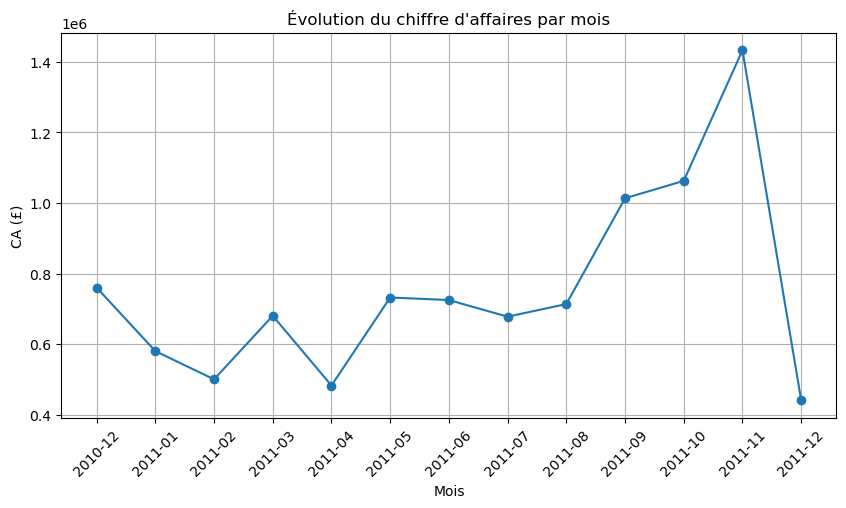

In [47]:
plt.figure(figsize=(10,5))
plt.plot(ca_mois["Mois"], ca_mois["Chiffre_Affaires"], marker="o")
plt.title("Évolution du chiffre d'affaires par mois")
plt.xlabel("Mois")
plt.ylabel("CA (£)")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

## Évolution du chiffre d'affaires par semaine 

In [48]:
query = """
SELECT
    strftime('%Y-%W', InvoiceDate) AS Semaine,
    ROUND(SUM(Quantity * UnitPrice), 2) AS Chiffre_Affaires
FROM online_retail_clean
GROUP BY Semaine
ORDER BY Semaine
"""
ca_semaine = pd.read_sql(query, conn)
ca_semaine

,Semaine,Chiffre_Affaires
0,2010-48,177970.89
1,2010-49,296838.64
2,2010-50,202839.14
3,2010-51,82754.38
4,2011-01,125780.39
5,2011-02,185334.03
6,2011-03,130796.83
7,2011-04,117337.62
8,2011-05,119185.93
9,2011-06,100439.42


## Graphique :

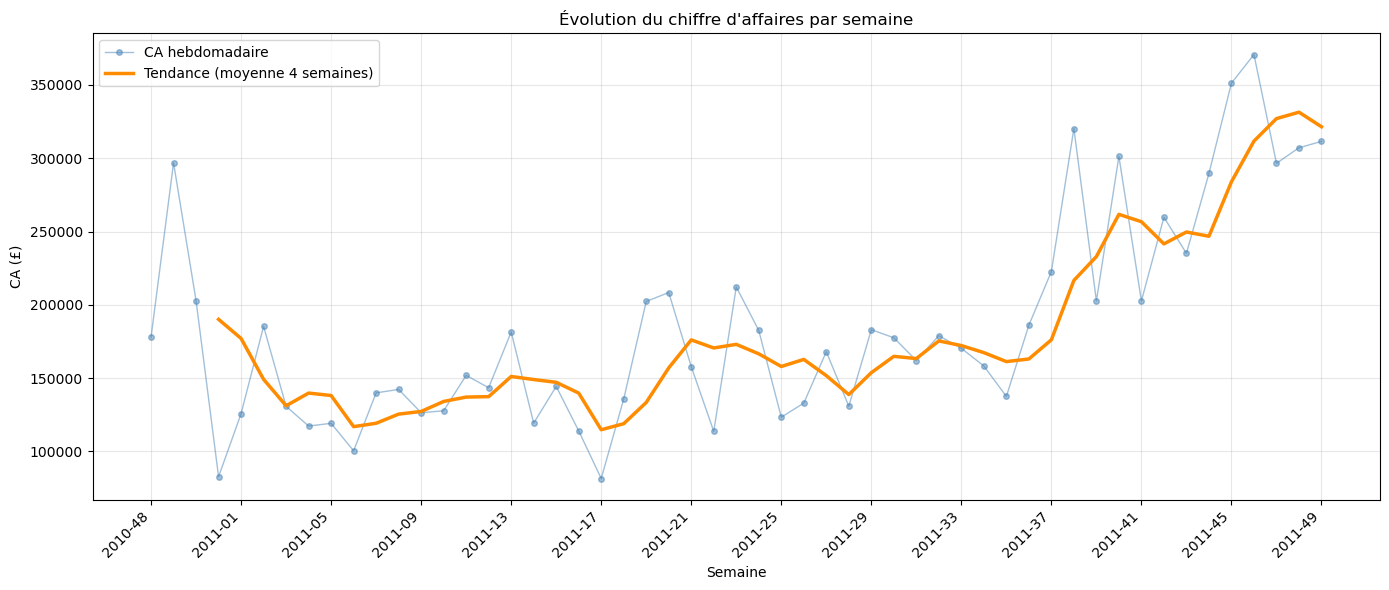

In [53]:
plt.figure(figsize=(14,6))

# Courbe brute, plus discrète
plt.plot(ca_semaine["Semaine"], ca_semaine["Chiffre_Affaires"],
          marker="o", markersize=4, linewidth=1, color="steelblue", alpha=0.5, label="CA hebdomadaire")

# Moyenne mobile sur 4 semaines pour lisser la tendance
ca_semaine["moyenne_mobile"] = ca_semaine["Chiffre_Affaires"].rolling(window=4).mean()
plt.plot(ca_semaine["Semaine"], ca_semaine["moyenne_mobile"],
          color="darkorange", linewidth=2.5, label="Tendance (moyenne 4 semaines)")

plt.title("Évolution du chiffre d'affaires par semaine")
plt.xlabel("Semaine")
plt.ylabel("CA (£)")

# N'afficher qu'une étiquette sur 4 pour la lisibilité
positions = range(0, len(ca_semaine), 4)
plt.xticks(positions, ca_semaine["Semaine"].iloc[positions], rotation=45, ha='right')

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Fréquence d'activités par heure

In [50]:
query = """
SELECT
    substr(invoiceHour, 1, 2) AS Heure,
    COUNT(DISTINCT InvoiceNo) AS Nombre_Commandes
FROM online_retail_clean
GROUP BY Heure
ORDER BY Heure
"""
heure = pd.read_sql(query, conn)
heure

,Heure,Nombre_Commandes
0,06,20
1,07,31
2,08,616
3,09,1687
4,10,2700
5,11,2840
6,12,3614
7,13,3120
8,14,2758
9,15,2660


## Graphique :

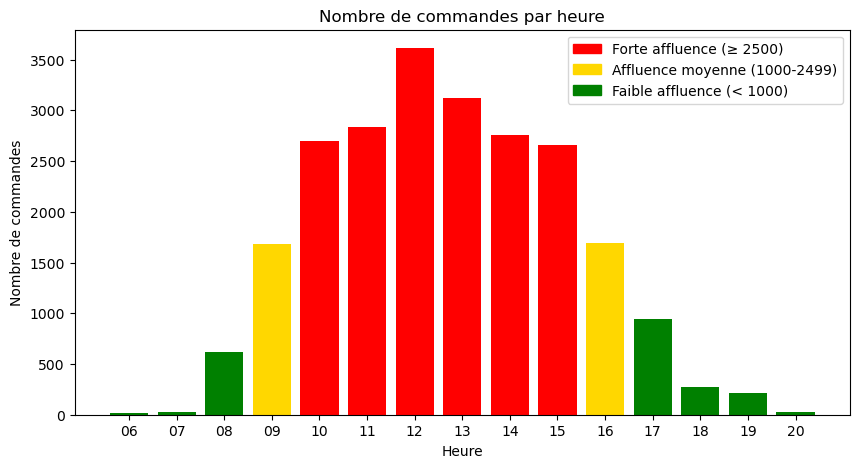

In [52]:
plt.figure(figsize=(10,5))

# Attribution des couleurs selon le niveau de commandes
def couleur_frequentation(valeur):
    if valeur >= 2500:
        return 'red'      # forte affluence
    elif valeur >= 1000:
        return 'gold'     # affluence moyenne
    else:
        return 'green'    # faible affluence

couleurs = [couleur_frequentation(v) for v in heure["Nombre_Commandes"]]

plt.bar(heure["Heure"], heure["Nombre_Commandes"], color=couleurs)
plt.title("Nombre de commandes par heure")
plt.xlabel("Heure")
plt.ylabel("Nombre de commandes")

# Légende manuelle (les couleurs seules ne suffisent pas à expliquer le code)
import matplotlib.patches as mpatches
legende = [
    mpatches.Patch(color='red', label='Forte affluence (≥ 2500)'),
    mpatches.Patch(color='gold', label='Affluence moyenne (1000-2499)'),
    mpatches.Patch(color='green', label='Faible affluence (< 1000)')
]
plt.legend(handles=legende)

plt.show()